In [1]:
import torch

from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.nn as nn
from torchlogix.layers import LogicConv2d, LogicDense, OrPooling2d, GroupSum
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
class LogicNet(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.features = nn.Sequential(
            LogicConv2d(
                in_dim=(28, 28),
                channels=1,
                num_kernels=16,
                tree_depth=3,
                receptive_field_size=5,
                padding=2
            ),
            OrPooling2d(kernel_size=2, stride=2, padding=0),

            LogicConv2d(
                in_dim=(14, 14),
                channels=16,
                num_kernels=32,
                tree_depth=3,
                receptive_field_size=3,
                padding=1
            ),
            OrPooling2d(kernel_size=2, stride=2, padding=0),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            LogicDense(in_dim=32*7*7, out_dim=1280),
            LogicDense(in_dim=1280, out_dim=640),
             LogicDense(in_dim=640, out_dim=320),
            GroupSum(num_classes, tau=1.0)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

# Create and use the model
model = LogicNet(num_classes=10)
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root="./data", train=False, download=True, transform=transform)



I0000 00:00:1777883552.055792    5762 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777883554.227013    5762 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
batch_size = 128
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=2e-2)
def load_n(loader, n):
    i = 0
    while i < n:
        for batch in loader:
            yield batch
            i+=1
            if i == n:
                return

def evaluate(loader, train_mode=False):
    orig_mode = model.training
    model.train(train_mode)

    total_loss = 0.0
    total_correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += loss_fn(logits, y).item() * y.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total += y.size(0)

    model.train(orig_mode)
    return total_loss / total, total_correct / total

num_iterations = 1000
metrics_every = 100
running_loss = 0.0
running_examples = 0
test_loss_acc = {
    "train_iteration": [],
    "test_acc_discrete": [],
    "test_loss_discrete": [],
    "test_acc_relaxed": [],
    "test_loss_relaxed": [],
}

for step, (x, y) in enumerate(load_n(train_loader, num_iterations), start=1):
    model.train()
    x, y = x.to(device), y.to(device)

    logits = model(x)
    loss = loss_fn(logits, y)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item() * y.size(0)
    running_examples += y.size(0)

    if step % metrics_every == 0:
        disc_loss, disc_acc = evaluate(test_loader, train_mode=False)
        relax_loss, relax_acc = evaluate(test_loader, train_mode=True)
        train_loss = running_loss / running_examples

        test_loss_acc["train_iteration"].append(step)
        test_loss_acc["test_acc_discrete"].append(disc_acc)
        test_loss_acc["test_loss_discrete"].append(disc_loss)
        test_loss_acc["test_acc_relaxed"].append(relax_acc)
        test_loss_acc["test_loss_relaxed"].append(relax_loss)

        print(
            f"iter {step:4d} | "
            f"train_loss {train_loss:.4f} | "
            f"test_acc_discrete {disc_acc:.4f} | test_loss_discrete {disc_loss:.4f} | "
            f"test_acc_relaxed {relax_acc:.4f} | test_loss_relaxed {relax_loss:.4f}"
        )

        running_loss = 0.0
        running_examples = 0


iter  100 | train_loss 1.9538 | test_acc_discrete 0.0725 | test_loss_discrete 4.3872 | test_acc_relaxed 0.6853 | test_loss_relaxed 1.2550
iter  200 | train_loss 0.8437 | test_acc_discrete 0.5954 | test_loss_discrete 1.2144 | test_acc_relaxed 0.8278 | test_loss_relaxed 0.6072
iter  300 | train_loss 0.5458 | test_acc_discrete 0.7643 | test_loss_discrete 0.7376 | test_acc_relaxed 0.8664 | test_loss_relaxed 0.4624
iter  400 | train_loss 0.4317 | test_acc_discrete 0.8120 | test_loss_discrete 0.6065 | test_acc_relaxed 0.8899 | test_loss_relaxed 0.3926
iter  500 | train_loss 0.3840 | test_acc_discrete 0.8368 | test_loss_discrete 0.5260 | test_acc_relaxed 0.8997 | test_loss_relaxed 0.3449
iter  600 | train_loss 0.3365 | test_acc_discrete 0.8695 | test_loss_discrete 0.4163 | test_acc_relaxed 0.9104 | test_loss_relaxed 0.3107
iter  700 | train_loss 0.3111 | test_acc_discrete 0.8753 | test_loss_discrete 0.3927 | test_acc_relaxed 0.9175 | test_loss_relaxed 0.2890
iter  800 | train_loss 0.3051 | te

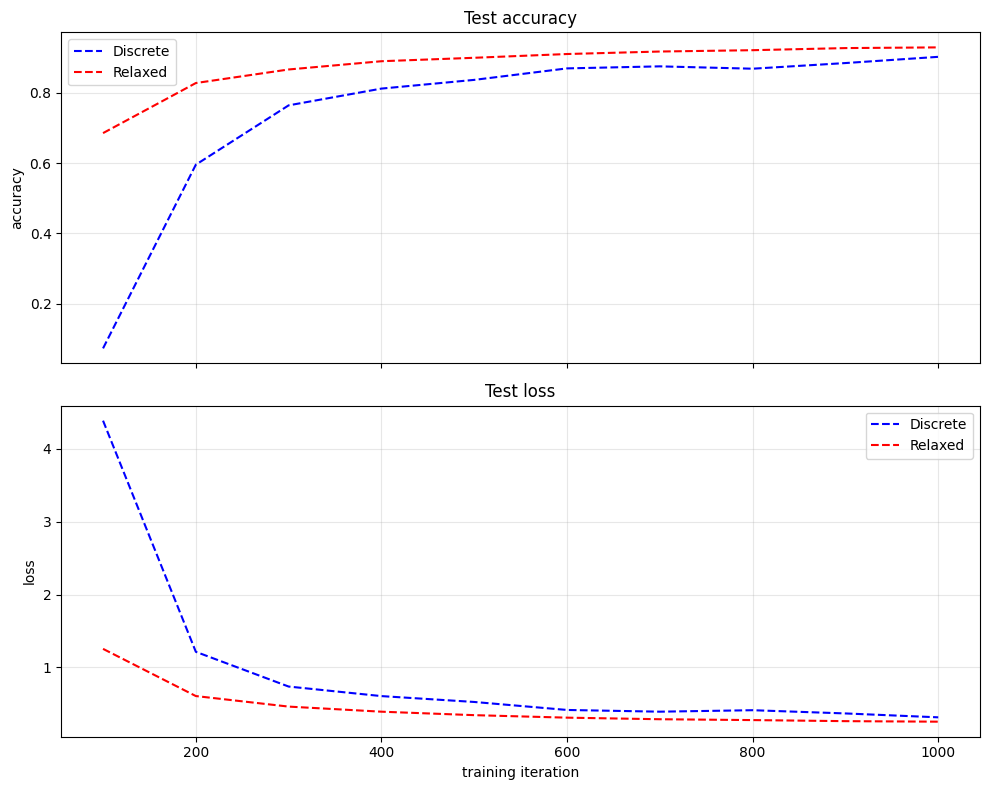

In [4]:
if not test_loss_acc["train_iteration"]:
    raise ValueError("Brak danych do wykresu. Najpierw uruchom komorke treningowa.")

fig, axes = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

axes[0].plot(test_loss_acc["train_iteration"], test_loss_acc["test_acc_discrete"], "--", c="b", label="Discrete")
axes[0].plot(test_loss_acc["train_iteration"], test_loss_acc["test_acc_relaxed"], "--", c="r", label="Relaxed")
axes[0].set_ylabel("accuracy")
axes[0].set_title("Test accuracy")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(test_loss_acc["train_iteration"], test_loss_acc["test_loss_discrete"], "--", c="b", label="Discrete")
axes[1].plot(test_loss_acc["train_iteration"], test_loss_acc["test_loss_relaxed"], "--", c="r", label="Relaxed")
axes[1].set_xlabel("training iteration")
axes[1].set_ylabel("loss")
axes[1].set_title("Test loss")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [6]:
image, label = test_dataset[3]

device = next(model.parameters()).device
loss_fn = nn.CrossEntropyLoss()
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

def evaluate_model(model, loader, loss_fn, device):
    was_training = model.training
    model.eval()

    total_loss = 0.0
    total_correct = 0
    total_examples = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)
            total_loss += loss_fn(logits, y).item() * y.size(0)
            total_correct += (logits.argmax(dim=1) == y).sum().item()
            total_examples += y.size(0)

    model.train(was_training)
    return total_loss / total_examples, total_correct / total_examples

test_loss, test_acc = evaluate_model(model, test_loader, loss_fn, device)
print(f"test loss: {test_loss:.4f}")
print(f"test accuracy: {test_acc:.4f}")

test loss: 0.3151
test accuracy: 0.9024


scores: [19.849745  9.784766 13.327803 15.337234 13.248017 13.578656 13.241045
 16.68928  12.891734 13.469267]
true label: 0, predicted: 0


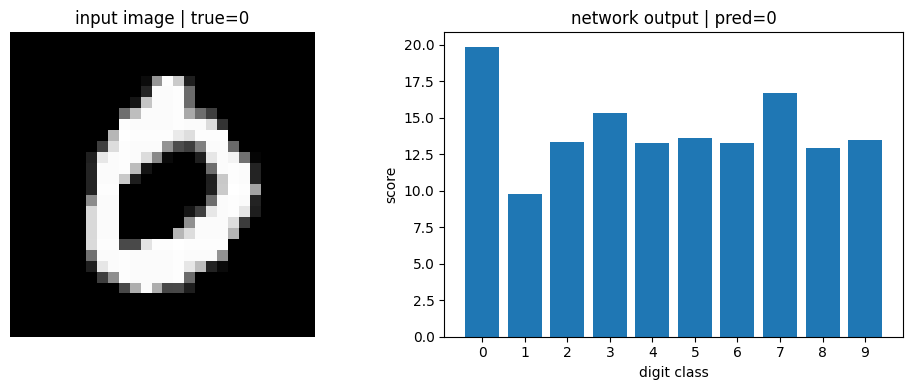

In [7]:
device = next(model.parameters()).device
was_training = model.training
model.eval()

with torch.no_grad():
    logits = model(image.unsqueeze(0).to(device))[0].detach().cpu()
    scores = logits.numpy()

model.train(was_training)

pred = int(scores.argmax())

print("scores:", scores)
print(f"true label: {label}, predicted: {pred}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(image.squeeze().numpy(), cmap="gray")
axes[0].set_title(f"input image | true={label}")
axes[0].axis("off")

axes[1].bar(range(len(scores)), scores)
axes[1].set_xticks(range(len(scores)))
axes[1].set_xlabel("digit class")
axes[1].set_ylabel("score")
axes[1].set_title(f"network output | pred={pred}")

plt.tight_layout()
plt.show()

softmax probabilities: [9.4150233e-01 4.0054998e-05 1.3847708e-03 1.0329105e-02 1.2785790e-03
 1.7795992e-03 1.2696953e-03 3.9925355e-02 8.9535600e-04 1.5951997e-03]


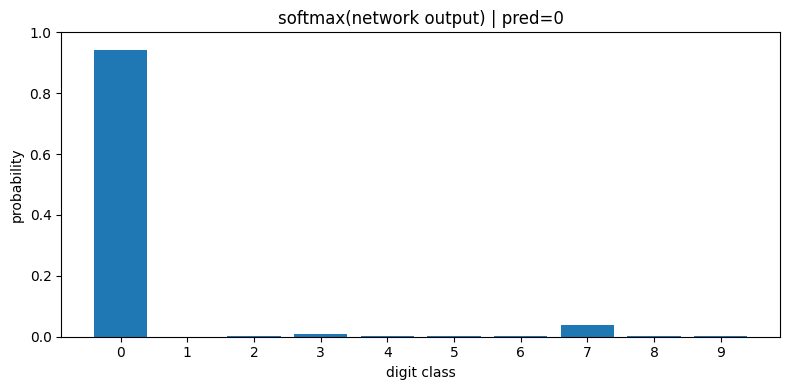

In [8]:
probabilities = torch.softmax(logits, dim=0).numpy()

print("softmax probabilities:", probabilities)

plt.figure(figsize=(8, 4))
plt.bar(range(len(probabilities)), probabilities)
plt.xticks(range(len(probabilities)))
plt.xlabel("digit class")
plt.ylabel("probability")
plt.title(f"softmax(network output) | pred={pred}")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()
